# 现代循环神经网络

**参考**: [动手学深度学习 第9章](https://zh-v2.d2l.ai/chapter_recurrent-modern/index.html)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import collections
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


数据准备（复用第7章的文本预处理）

In [7]:
# 语料与词表（与第7章相同）
TEXT = """
the time machine by h g wells
the time traveller for so it will be convenient to speak of him
was expounding a recondite matter to us there were four of us
the thing that shall not be named and the medical man
and i was standing on one side of the fire and the psychologist
was on the other side of the fire and i said to them
i have a theory about the fourth dimension and about the time
travel through it and i have verified it experimentally i have
invented a machine that can travel through time he said
we naturally could not believe him but we listened politely
the time traveller held in his hand a glittering metallic framework
scarcely larger than a small clock and very delicately made
there is a model of my time machine he said and presently
he took it up and showed it to us it was beautifully made
and there were two great white levers and a saddle and
some sort of small apparatus with dials and tubes attached
we all sat looking at the machine and wondering what it could do
the time traveller looked at us and then at the machine and laughed
"""

def tokenize(text, token_type='char'):
    text = text.strip().lower().replace(' ', '_')
    if token_type == 'char':
        return list(text)
    else:
        return text.split('_')

class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=None):
        reserved_tokens = reserved_tokens or []
        counter = collections.Counter(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {t: i for i, t in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if isinstance(tokens, (list, tuple)):
            return [self[t] for t in tokens]
        return self.token_to_idx.get(tokens, 0)

    def to_tokens(self, indices):
        if isinstance(indices, (list, tuple)):
            return [self.idx_to_token[i] for i in indices]
        return self.idx_to_token[indices]

char_tokens = tokenize(TEXT)
vocab = Vocab(char_tokens)
corpus = vocab[char_tokens]
print(f'词表大小: {len(vocab)}, 语料长度: {len(corpus)}')

词表大小: 26, 语料长度: 1058


In [8]:
# 数据迭代器
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """顺序采样"""
    offset = random.randint(0, num_steps - 1)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset:offset + num_tokens]).reshape(batch_size, -1)
    Ys = torch.tensor(corpus[offset + 1:offset + 1 + num_tokens]).reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i:i + num_steps]
        Y = Ys[:, i:i + num_steps]
        yield X, Y

# 通用训练函数
def train_rnn(model, corpus, vocab, num_epochs=200, lr=1e-3,
              batch_size=8, num_steps=35, clipping_theta=1.0):
    """训练 RNN 语言模型，返回困惑度历史"""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    ppl_history = []

    for epoch in range(num_epochs):
        total_loss, total_tokens = 0.0, 0
        state = None
        for X, Y in seq_data_iter_sequential(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.to(device)
            if state is not None:
                if isinstance(state, tuple):
                    state = tuple(s.detach() for s in state)
                else:
                    state = state.detach()
            y_hat, state = model(X, state)
            loss = loss_fn(y_hat.reshape(-1, y_hat.shape[-1]), Y.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clipping_theta)
            optimizer.step()
            total_loss += loss.item() * Y.numel()
            total_tokens += Y.numel()
        ppl = math.exp(total_loss / total_tokens)
        ppl_history.append(ppl)
        if (epoch + 1) % 50 == 0:
            pred = predict(model, list('the_'), vocab, 50)
            print(f'epoch {epoch+1}, ppl {ppl:.1f}, predict: {pred}')
    return ppl_history

def predict(model, prefix, vocab, num_preds):
    """基于前缀生成后续字符"""
    model.eval()
    state = None
    outputs = [vocab[prefix[0]]]
    for t in range(len(prefix) - 1 + num_preds):
        X = torch.tensor([[outputs[-1]]], device=device)
        with torch.no_grad():
            y_hat, state = model(X, state)
        if t < len(prefix) - 1:
            outputs.append(vocab[prefix[t + 1]])
        else:
            outputs.append(int(y_hat.argmax(dim=-1).item()))
    model.train()
    return ''.join(vocab.to_tokens(outputs))

---
### 8.1 门控循环单元 GRU <a id='gru'></a>

标准 RNN 在长序列上存在**梯度消失/爆炸**问题，难以捕捉长距离依赖。GRU 通过引入**门控机制**来解决这一问题。针对这一问题，GRU 使用两个门来控制信息流：

| 门 | 公式 | 作用 |
|---|------|------|
| **重置门** $R_t$ | $R_t = \sigma(X_t W_{xr} + H_{t-1} W_{hr} + b_r)$ | 控制"忘记多少过去" |
| **更新门** $Z_t$ | $Z_t = \sigma(X_t W_{xz} + H_{t-1} W_{hz} + b_z)$ | 控制"保留多少过去" |


![gru](assets/gru-3.svg)

**候选隐状态与最终隐状态：

$$\tilde{H}_t = \tanh(X_t W_{xh} + (R_t \odot H_{t-1}) W_{hh} + b_h)$$

$$H_t = Z_t \odot H_{t-1} + (1 - Z_t) \odot \tilde{H}_t$$

直觉理解：
- 当 $Z_t \approx 1$ 时，旧状态被保留（跳过当前输入） → 捕捉**长期依赖**
- 当 $Z_t \approx 0$ 时，候选状态替换旧状态 → 响应**短期变化**
- 当 $R_t \approx 0$ 时，候选状态忽略旧隐状态 → 相当于"重置"

In [9]:
# ========== PyTorch 简洁实现 GRU ==========

class GRUModel(nn.Module):
    """基于 nn.GRU 的字符级语言模型"""
    def __init__(self, vocab_size, num_hiddens, num_layers=1):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.rnn = nn.GRU(vocab_size, num_hiddens, num_layers, batch_first=True)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, X, state=None):
        X = F.one_hot(X.long(), self.vocab_size).float()
        output, state = self.rnn(X, state)
        y_hat = self.linear(output)
        return y_hat, state

# 训练 GRU
gru_model = GRUModel(len(vocab), 256)
gru_ppl = train_rnn(gru_model, corpus, vocab, num_epochs=200, lr=1e-3)

epoch 50, ppl 6.8, predict: the_the_time_the_time_the_time_the_time_the_time_the_t
epoch 100, ppl 1.8, predict: the_time_thave_iere_trlly_he_thandin_hat_wan_thavei_ha
epoch 150, ppl 1.2, predict: the_machine_a_dheory_hall_the_thing_that_shall_not_be_
epoch 200, ppl 1.1, predict: the_time_traveller_for_so_it_will_be_convenient_to_spe


---
### 8.2 长短期记忆网络 LSTM <a id='lstm'></a>

LSTM 比 GRU 更早提出（1997），引入**记忆元** $C_t$ 作为独立于隐状态的长期记忆通道，使用三个门控制信息流。


| 门 | 公式 | 作用 |
|---|------|------|
| **输入门** $I_t$ | $I_t = \sigma(X_t W_{xi} + H_{t-1} W_{hi} + b_i)$ | 决定多少新信息写入记忆元 |
| **忘记门** $F_t$ | $F_t = \sigma(X_t W_{xf} + H_{t-1} W_{hf} + b_f)$ | 决定多少旧信息从记忆元丢弃 |
| **输出门** $O_t$ | $O_t = \sigma(X_t W_{xo} + H_{t-1} W_{ho} + b_o)$ | 决定多少记忆元信息输出到隐状态 |

![lstm](assets/lstm-2.svg)


**候选记忆元、记忆元更新、隐状态**：

$$\tilde{C}_t = \tanh(X_t W_{xc} + H_{t-1} W_{hc} + b_c)$$

$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t$$

$$H_t = O_t \odot \tanh(C_t)$$

与 GRU 的对比：
- GRU 用 2 个门（重置 + 更新），LSTM 用 3 个门（输入 + 忘记 + 输出）
- LSTM 多了独立的记忆元 $C_t$，梯度通过 $C_t$ 的加法通道更容易回传
- GRU 参数更少、训练更快；LSTM 表达能力更强

In [10]:
# ========== PyTorch 简洁实现 LSTM ==========

class LSTMModel(nn.Module):
    """基于 nn.LSTM 的字符级语言模型"""
    def __init__(self, vocab_size, num_hiddens, num_layers=1):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.rnn = nn.LSTM(vocab_size, num_hiddens, num_layers, batch_first=True)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, X, state=None):
        X = F.one_hot(X.long(), self.vocab_size).float()
        output, state = self.rnn(X, state)
        y_hat = self.linear(output)
        return y_hat, state

# 训练 LSTM
lstm_model = LSTMModel(len(vocab), 256)
lstm_ppl = train_rnn(lstm_model, corpus, vocab, num_epochs=200, lr=1e-3)

epoch 50, ppl 9.0, predict: the_the_tine_the_te_te_te_te_te_te_te_te_te_te_te_te_t
epoch 100, ppl 3.7, predict: the_ther__and_soand_t_ao_time_thave_thrre_ood_i__axlll
epoch 150, ppl 1.9, predict: the_time_traveller_for_so_it_will_be_aoveninng_t_s_sel
epoch 200, ppl 1.3, predict: the_time_traveller_for_so_it_will_be_convenient_to_spe


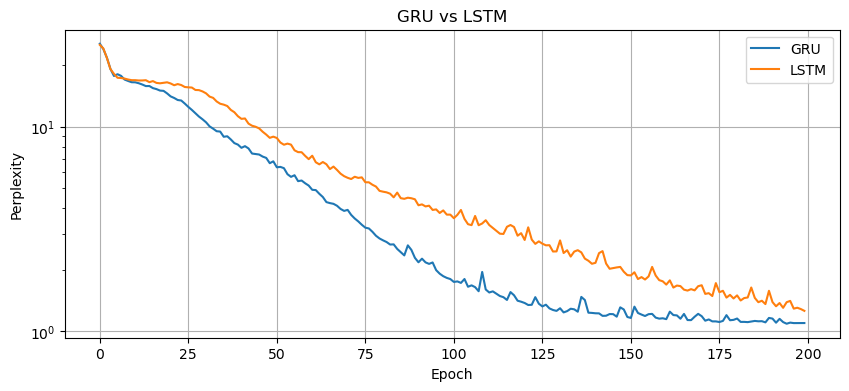

In [11]:
# GRU vs LSTM 训练曲线对比
plt.figure(figsize=(10, 4))
plt.plot(gru_ppl, label='GRU')
plt.plot(lstm_ppl, label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('GRU vs LSTM')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

---
### 8.3 深度循环神经网络 <a id='deep-rnn'></a>

将多个 RNN 层堆叠起来，形成深度 RNN：

$$H_t^{(l)} = \phi_l(H_t^{(l-1)} W_{xh}^{(l)} + H_{t-1}^{(l)} W_{hh}^{(l)} + b_h^{(l)})$$

其中 $H_t^{(0)} = X_t$（输入），$L$ 为层数。最终输出：

$$O_t = H_t^{(L)} W_{hq} + b_q$$


![deep-rnn](assets/deep-rnn.svg)

每层的隐状态信息**同时传递**给：
1. 当前层的下一个时间步
2. 下一层的当前时间步

在 PyTorch 中只需设置 `num_layers` 参数。

epoch 50, ppl 7.5, predict: the_time_the_time_the_time_the_time_the_time_the_time_
epoch 100, ppl 1.9, predict: the_time_traveller_for_so_it_will_be_convenient_the_sa
epoch 150, ppl 1.1, predict: the_time_traveller_for_so_it_will_be_convenient_to_spe
epoch 200, ppl 1.1, predict: the_time_traveller_for_so_it_will_be_convenient_to_spe


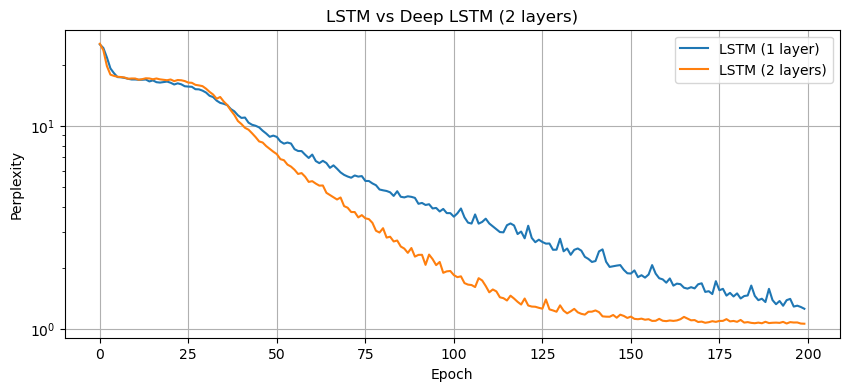

In [12]:
# 2 层 LSTM
deep_lstm = LSTMModel(len(vocab), 256, num_layers=2)
deep_ppl = train_rnn(deep_lstm, corpus, vocab, num_epochs=200, lr=1e-3)

# 对比
plt.figure(figsize=(10, 4))
plt.plot(lstm_ppl, label='LSTM (1 layer)')
plt.plot(deep_ppl, label='LSTM (2 layers)')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('LSTM vs Deep LSTM (2 layers)')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

---
### 8.4 双向循环神经网络 <a id='bi-rnn'></a>

双向 RNN 同时从**正向和反向**处理序列：

$$\overrightarrow{H}_t = \phi(X_t W_{xh}^{(f)} + \overrightarrow{H}_{t-1} W_{hh}^{(f)} + b_h^{(f)})$$

$$\overleftarrow{H}_t = \phi(X_t W_{xh}^{(b)} + \overleftarrow{H}_{t+1} W_{hh}^{(b)} + b_h^{(b)})$$

$$H_t = [\overrightarrow{H}_t, \overleftarrow{H}_t] \in \mathbb{R}^{n \times 2h}$$

$$O_t = H_t W_{hq} + b_q$$



![bi-rnn](assets/birnn.svg)

> **重要警告**：双向 RNN **不能用于预测/生成任务**（如语言模型），因为预测时看不到未来信息。
> 它适用于**序列编码**任务（如命名实体识别、机器翻译的编码端）。

In [ ]:
# 双向 LSTM 演示（注意：用于语言模型效果不好，仅做结构演示）
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens, num_layers=1):
        super().__init__()
        self.vocab_size = vocab_size
        self.rnn = nn.LSTM(vocab_size, num_hiddens, num_layers,
                           batch_first=True, bidirectional=True)
        # 注意：双向 LSTM 输出维度是 2 * num_hiddens
        self.linear = nn.Linear(2 * num_hiddens, vocab_size)

    def forward(self, X, state=None):
        X = F.one_hot(X.long(), self.vocab_size).float()
        output, state = self.rnn(X, state)
        y_hat = self.linear(output)
        return y_hat, state

bi_model = BiLSTMModel(len(vocab), 256)
bi_ppl = train_rnn(bi_model, corpus, vocab, num_epochs=200, lr=1e-3)

# 双向RNN用于语言模型的困惑度会偏高，因为它会"作弊"看到未来token
# 但在序列标注等任务中表现优异
print(f'\n注意: 双向RNN不适合语言模型任务，此处仅演示结构')

---
### 8.5 机器翻译任务与seq2seq模型 <a id='mt-dataset'></a>

机器翻译是RNN学习的典型应用,但是常规的RNN模型在处理机器翻译时，会遇到序列长度不对等的问题，在这里需要进一步的处理和设计。

数据处理流程：
1. **预处理**：统一大小写、处理标点前空格
2. **词元化**：机器翻译通常使用**词级别**而非字符级别
3. **构建词表**：源语言和目标语言各有独立词表，加入特殊标记 `<pad>`, `<bos>`, `<eos>`
4. **截断/填充**：将序列统一到固定长度 `num_steps`
5. **有效长度**：记录每个序列实际（非填充）的长度

In [13]:
# 使用一个小型英法翻译数据集
raw_data = """
go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !
fire !	au feu !
help !	à l'aide !
jump .	saute .
stop !	arrête-toi !
stop !	arrêtez-vous !
wait !	attends !
wait !	attendez !
i ran .	j'ai couru .
i see .	je vois .
i try .	j'essaye .
i won !	j'ai gagné !
i see .	je comprends .
he ran .	il a couru .
he won .	il a gagné .
i'm ok .	je vais bien .
i'm ill .	je suis malade .
i'm old .	je suis vieux .
come on .	viens !
get out .	sors !
get out .	sortez !
go away .	va-t'en !
go home .	rentre chez toi .
help me .	aidez-moi .
hold on .	attends .
hug me .	serre-moi dans tes bras .
i agree .	je suis d'accord .
i'm fat .	je suis gros .
i'm hot .	j'ai chaud .
it's ok .	c'est bon .
keep it .	garde-le .
let go .	lâche-moi .
listen .	écoutez .
really ?	vraiment ?
relax .	relaxe-toi .
shut up .	tais-toi .
sit down .	assieds-toi .
i'm busy .	je suis occupé .
i'm cold .	j'ai froid .
i'm fine .	je vais bien .
i'm home .	je suis chez moi .
i'm lazy .	je suis paresseux .
i'm lost .	je suis perdu .
i'm rich .	je suis riche .
i'm sick .	je suis malade .
i'm tired .	je suis fatigué .
i'm young .	je suis jeune .
it's cold .	il fait froid .
it's warm .	il fait chaud .
leave me .	laisse-moi .
may i go ?	puis-je partir ?
he is old .	il est vieux .
he is shy .	il est timide .
he's calm .	il est calme .
i forgot .	j'ai oublié .
i'll pay .	je paierai .
i lost .	j'ai perdu .
""".strip()

def preprocess_nmt(text):
    """预处理翻译数据"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    text = text.lower()
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def tokenize_nmt(text):
    """词元化翻译数据"""
    source, target = [], []
    for line in text.split('\n'):
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

processed = preprocess_nmt(raw_data)
source, target = tokenize_nmt(processed)
print(f'样本数: {len(source)}')
for i in range(5):
    print(f'  en: {source[i]}  →  fr: {target[i]}')

样本数: 62
  en: ['go', '.']  →  fr: ['va', '!']
  en: ['hi', '.']  →  fr: ['salut', '!']
  en: ['run', '!']  →  fr: ['cours', '!']
  en: ['run', '!']  →  fr: ['courez', '!']
  en: ['who', '?']  →  fr: ['qui', '?']


In [14]:
# 构建源语言和目标语言词表
src_vocab = Vocab([t for s in source for t in s], min_freq=1,
                  reserved_tokens=['<pad>', '<bos>', '<eos>'])
tgt_vocab = Vocab([t for s in target for t in s], min_freq=1,
                  reserved_tokens=['<pad>', '<bos>', '<eos>'])
print(f'源语言词表大小: {len(src_vocab)}, 目标语言词表大小: {len(tgt_vocab)}')

def truncate_pad(line, num_steps, padding_token):
    """截断或填充序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def build_array_nmt(lines, vocab, num_steps):
    """将文本序列转换为定长张量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).sum(dim=1)
    return array, valid_len

# 构建数据
num_steps = 10
src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
print(f'源序列形状: {src_array.shape}, 目标序列形状: {tgt_array.shape}')
print(f'示例 - 源: {src_array[0]}, 有效长度: {src_valid_len[0]}')
print(f'示例 - 目标: {tgt_array[0]}, 有效长度: {tgt_valid_len[0]}')

源语言词表大小: 69, 目标语言词表大小: 78
源序列形状: torch.Size([62, 10]), 目标序列形状: torch.Size([62, 10])
示例 - 源: tensor([8, 4, 3, 1, 1, 1, 1, 1, 1, 1]), 有效长度: 3
示例 - 目标: tensor([25,  6,  3,  1,  1,  1,  1,  1,  1,  1]), 有效长度: 3


In [15]:
# 构建 DataLoader
from torch.utils.data import TensorDataset, DataLoader

batch_size = 4
dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)
train_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for X, X_vlen, Y, Y_vlen in train_iter:
    print(f'X: {X.shape}, X_valid_len: {X_vlen}')
    print(f'Y: {Y.shape}, Y_valid_len: {Y_vlen}')
    break

X: torch.Size([4, 10]), X_valid_len: tensor([4, 4, 4, 3])
Y: torch.Size([4, 10]), Y_valid_len: tensor([3, 3, 5, 3])


**编码器-解码器架构**

对于输入输出序列长度不对等的问题，研究者提出了**编码器-解码器**架构，该架构是处理**输入输出长度不同**的序列任务的通用框架：

- **编码器**（Encoder）：将变长输入序列编码为固定形状的**上下文变量** $c$
- **解码器**（Decoder）：将上下文变量 $c$ 解码为变长输出序列



In [16]:
# 编码器-解码器基类

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, X, *args):
        raise NotImplementedError

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
    def init_state(self, enc_outputs, *args):
        raise NotImplementedError
    def forward(self, X, state):
        raise NotImplementedError

class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

---
**Seq2Seq模型**

进一步的，Seq2Seq 使用 RNN 实现编码器-解码器架构，进而用于机器翻译任务等，其结构为。



![](assets/seq2seq.svg)


**编码器**
- 嵌入层 + 多层 GRU
- 上下文变量 $c = h_T$（最后时间步的隐状态）

**解码器**
- 每一步将输入嵌入与上下文 $c$ 拼接后送入 GRU
- 训练时使用 **Teacher Forcing**：解码器输入是目标序列的真实值（而非上一步预测值）

**损失函数**
- 使用 **Masked Softmax Cross-Entropy**：填充位置不参与损失计算

**评估指标 —— BLEU**

$$\text{BLEU} = \exp\left(\min\left(0,\, 1 - \frac{\text{len}_{\text{label}}}{\text{len}_{\text{pred}}}\right)\right) \prod_{n=1}^{k} p_n^{1/2^n}$$

其中 $p_n$ 是 n-gram 精确率。简短惩罚因子防止模型偏好过短的翻译。

In [17]:
# ========== Seq2Seq 编码器 ==========

class Seq2SeqEncoder(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers,
                          dropout=dropout, batch_first=True)

    def forward(self, X, *args):
        # X: (batch, seq_len)
        X = self.embedding(X)   # (batch, seq_len, embed)
        output, state = self.rnn(X)
        # output: (batch, seq_len, hidden), state: (num_layers, batch, hidden)
        return output, state

# 测试编码器
encoder = Seq2SeqEncoder(len(src_vocab), embed_size=32, num_hiddens=64,
                         num_layers=2, dropout=0.1)
encoder.eval()
X_demo = torch.zeros((4, 7), dtype=torch.long)
output, state = encoder(X_demo)
print(f'编码器输出: {output.shape}, 隐状态: {state.shape}')

编码器输出: torch.Size([4, 7, 64]), 隐状态: torch.Size([2, 4, 64])


In [18]:
# ========== Seq2Seq 解码器 ==========

class Seq2SeqDecoder(Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 输入 = embed + context(num_hiddens)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers,
                          dropout=dropout, batch_first=True)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, *args):
        # 取编码器最终隐状态作为解码器初始状态
        return enc_outputs[1]  # (num_layers, batch, hidden)

    def forward(self, X, state):
        # X: (batch, seq_len)
        X = self.embedding(X)  # (batch, seq_len, embed)
        # 取最后一层隐状态作为 context，广播到每个时间步
        context = state[-1].unsqueeze(1).repeat(1, X.shape[1], 1)  # (batch, seq_len, hidden)
        X_and_context = torch.cat((X, context), dim=2)
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output)  # (batch, seq_len, vocab)
        return output, state

# 测试解码器
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size=32, num_hiddens=64,
                         num_layers=2, dropout=0.1)
decoder.eval()
dec_state = decoder.init_state((output, state))
dec_output, dec_state = decoder(torch.zeros((4, 7), dtype=torch.long), dec_state)
print(f'解码器输出: {dec_output.shape}, 隐状态: {dec_state.shape}')

解码器输出: torch.Size([4, 7, 78]), 隐状态: torch.Size([2, 4, 64])


In [19]:
# ========== 带掩码的损失函数 ==========

def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带掩码的交叉熵损失：填充位置不参与损失计算"""
    def forward(self, pred, label, valid_len):
        # pred: (batch, seq_len, vocab_size)
        # label: (batch, seq_len)
        weights = torch.ones_like(label, dtype=torch.float32)
        weights = sequence_mask(weights, valid_len)
        self.reduction = 'none'
        # CrossEntropyLoss 需要 (batch, classes, seq_len)
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

# 验证掩码效果
loss_fn = MaskedSoftmaxCELoss()
pred = torch.randn(3, 4, 10)
label = torch.ones(3, 4, dtype=torch.long)
valid_len = torch.tensor([4, 2, 0])
print(f'掩码损失: {loss_fn(pred, label, valid_len)}')

掩码损失: tensor([2.8318, 2.1970, 0.0000])


In [20]:
# ========== Seq2Seq 训练 ==========

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练 Seq2Seq 模型"""
    # Xavier 初始化
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for name, param in m.named_parameters():
                if 'weight' in name:
                    nn.init.xavier_uniform_(param)
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    loss_history = []

    for epoch in range(num_epochs):
        total_loss, total_tokens = 0.0, 0
        for batch in data_iter:
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            # Teacher Forcing: 解码器输入 = <bos> + Y[:-1]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], dim=1)
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            optimizer.zero_grad()
            l.sum().backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            with torch.no_grad():
                total_loss += l.sum().item()
                total_tokens += Y_valid_len.sum().item()
        avg_loss = total_loss / total_tokens
        loss_history.append(avg_loss)
        if (epoch + 1) % 50 == 0:
            print(f'epoch {epoch+1}, loss {avg_loss:.3f}')
    return loss_history

# 构建并训练模型
embed_size, num_hiddens, num_layers, dropout = 32, 64, 2, 0.1
lr, num_epochs = 0.005, 300

encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

seq2seq_loss = train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

epoch 50, loss 0.004
epoch 100, loss 0.004
epoch 150, loss 0.004
epoch 200, loss 0.003
epoch 250, loss 0.012
epoch 300, loss 0.004


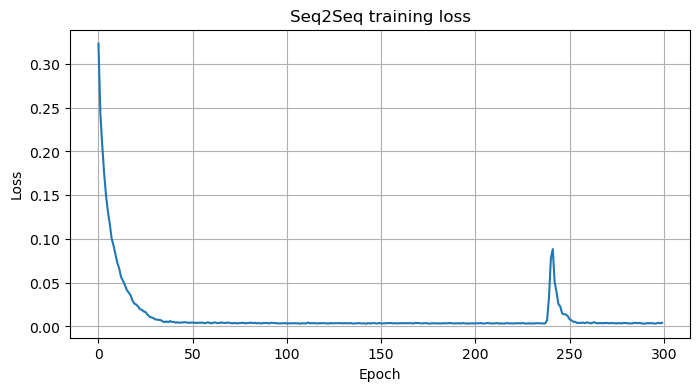

In [21]:
# 训练损失曲线
plt.figure(figsize=(8, 4))
plt.plot(seq2seq_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Seq2Seq training loss')
plt.grid(True)
plt.show()

In [22]:
# ========== Seq2Seq 预测 ==========

def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps, device):
    """贪心解码预测"""
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [src_vocab['<eos>']]
    src_tokens = truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    enc_X = torch.tensor(src_tokens, dtype=torch.long, device=device).unsqueeze(0)
    enc_outputs = net.encoder(enc_X)
    dec_state = net.decoder.init_state(enc_outputs)
    # 解码器第一个输入是 <bos>
    dec_X = torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device).unsqueeze(0)
    output_seq = []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        dec_X = Y.argmax(dim=2)  # 贪心：取概率最大的词
        pred = dec_X.squeeze(0).item()
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq))

# ========== BLEU 评分 ==========

def bleu(pred_seq, label_seq, k):
    """计算 BLEU 分数"""
    pred_tokens = pred_seq.split(' ')
    label_tokens = label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    # 简短惩罚
    score = math.exp(min(0, 1 - len_label / max(len_pred, 1)))
    for n in range(1, k + 1):
        num_matches = 0
        label_subs = collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i:i + n])] += 1
        for i in range(len_pred - n + 1):
            key = ' '.join(pred_tokens[i:i + n])
            if label_subs[key] > 0:
                num_matches += 1
                label_subs[key] -= 1
        denom = max(len_pred - n + 1, 1)
        score *= math.pow(num_matches / denom, math.pow(0.5, n))
    return score

# 翻译测试
test_pairs = [
    ('go .', 'va !'),
    ('i lost .', "j'ai perdu ."),
    ("he's calm .", 'il est calme .'),
    ("i'm home .", 'je suis chez moi .'),
]

for eng, fra in test_pairs:
    translation = predict_seq2seq(net, eng, src_vocab, tgt_vocab, num_steps, device)
    score = bleu(translation, fra, k=2)
    print(f'{eng} => {translation}, BLEU={score:.3f}')

go . => va !, BLEU=1.000
i lost . => j'ai perdu ., BLEU=1.000
he's calm . => il est calme ., BLEU=1.000
i'm home . => je suis chez moi ., BLEU=1.000


---
### 8.6 束搜索 (Beam Search) <a id='beam-search'></a>

上面的预测使用**贪心搜索**：每步选概率最高的词。但贪心搜索不一定找到全局最优序列。


### 束搜索算法

维护 $k$（束宽）个候选序列：

1. **初始**：选择概率最高的 $k$ 个词作为 $k$ 条候选
2. **每步**：对每条候选扩展所有可能的下一个词，共 $k \cdot |\mathcal{Y}|$ 个候选
3. **筛选**：从中选出联合概率最高的 $k$ 个保留
4. **终止**：当候选遇到 `<eos>` 时，将其加入最终候选集

为避免偏好短序列，使用**长度归一化**的得分：

$$\frac{1}{L^\alpha} \log P(y_1, \ldots, y_L \mid c) = \frac{1}{L^\alpha} \sum_{t'=1}^{L} \log P(y_{t'} \mid y_1, \ldots, y_{t'-1}, c)$$

其中 $\alpha$ 通常取 0.75。